# Notebook 04 — DistilBERT Fine-Tuning (Kaggle GPU)
**Project:** Product Review Sentiment Classification  
**Student:** Eeman Khalid (22F-3173) | BAI-8A  

Fine-tunes **`distilbert-base-uncased`** for 3-class sentiment classification.  
⚠️ **Run this on Kaggle with GPU enabled (T4). Runtime: ~45–70 minutes.**  

**After training, download the entire `bert/` folder from Output:**
- `bert/config.json`
- `bert/model.safetensors`
- `bert/tokenizer_config.json`
- `bert/tokenizer.json`
- `bert/vocab.txt`
- `bert_confusion_test.png`
- `bert_training_curves.png`
- `bert_results.json`

In [1]:
pip install -U transformers sentence-transformers --quiet

Note: you may need to restart the kernel to use updated packages.


In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/f223173eemankhalid/amazon-sentiment-processed/amazon_clean.csv


In [7]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch: 2.10.0+cu128
Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [8]:
# ── Paths & Config ────────────────────────────────────────────────────────
DATA_PATH  = '/kaggle/input/datasets/f223173eemankhalid/amazon-sentiment-processed/amazon_clean.csv'
OUTPUT_DIR = '/kaggle/working/'
BERT_DIR   = OUTPUT_DIR + 'bert/'
os.makedirs(BERT_DIR, exist_ok=True)

CONFIG = {
    'model_name':    'distilbert-base-uncased',
    'num_labels':    3,
    'max_seq_len':   128,
    'batch_size':    32,
    'epochs':        4,
    'lr':            2e-5,
    'warmup_ratio':  0.1,
    'weight_decay':  0.01,
    'patience':      2,
}
LABEL_NAMES   = ['negative', 'neutral', 'positive']
LABEL_MAP_INV = {0: 'negative', 1: 'neutral', 2: 'positive'}
print('Config:', CONFIG)

Config: {'model_name': 'distilbert-base-uncased', 'num_labels': 3, 'max_seq_len': 128, 'batch_size': 32, 'epochs': 4, 'lr': 2e-05, 'warmup_ratio': 0.1, 'weight_decay': 0.01, 'patience': 2}


In [9]:
# ── Load data ─────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df):,} rows')
print(df['sentiment'].value_counts())

# BERT uses raw text (not clean_text) — tokenizer handles subword splitting
X = df['text'].fillna('').values
y = df['label'].values

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42)
print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')

Loaded 1,176 rows
sentiment
positive    741
neutral     360
negative     75
Name: count, dtype: int64
Train: 822 | Val: 177 | Test: 177


In [10]:
# ── Tokenizer ─────────────────────────────────────────────────────────────
print(f'Loading tokenizer: {CONFIG["model_name"]}')
tokenizer = DistilBertTokenizerFast.from_pretrained(CONFIG['model_name'])
print('Tokenizer loaded.')

Loading tokenizer: distilbert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded.


In [11]:
# ── Dataset ───────────────────────────────────────────────────────────────
class BertReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        print(f'  Tokenizing {len(texts):,} samples...')
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

MAX_LEN = CONFIG['max_seq_len']
print('Tokenizing train...')
train_ds = BertReviewDataset(X_train, y_train, tokenizer, MAX_LEN)
print('Tokenizing val...')
val_ds   = BertReviewDataset(X_val,   y_val,   tokenizer, MAX_LEN)
print('Tokenizing test...')
test_ds  = BertReviewDataset(X_test,  y_test,  tokenizer, MAX_LEN)

BATCH = CONFIG['batch_size']
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
print(f'Dataloaders ready. Train batches: {len(train_loader)}')

Tokenizing train...
  Tokenizing 822 samples...
Tokenizing val...
  Tokenizing 177 samples...
Tokenizing test...
  Tokenizing 177 samples...
Dataloaders ready. Train batches: 26


In [12]:
# ── Model ─────────────────────────────────────────────────────────────────
print(f'Loading model: {CONFIG["model_name"]}')
model = DistilBertForSequenceClassification.from_pretrained(
    CONFIG['model_name'],
    num_labels=CONFIG['num_labels']
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total_params:,}')
print(f'Trainable params: {trainable_params:,}')

Loading model: distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params    : 66,955,779
Trainable params: 66,955,779


In [13]:
# ── Optimizer + Scheduler ─────────────────────────────────────────────────
optimizer     = AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
total_steps   = len(train_loader) * CONFIG['epochs']
warmup_steps  = int(CONFIG['warmup_ratio'] * total_steps)
scheduler     = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

print(f'Total training steps : {total_steps}')
print(f'Warmup steps         : {warmup_steps}')

Total training steps : 104
Warmup steps         : 10


In [14]:
# ── Training utilities ────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total

def eval_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['labels'].to(DEVICE)
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss    += outputs.loss.item()
            preds          = outputs.logits.argmax(dim=1)
            correct       += (preds == labels).sum().item()
            total         += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss/len(loader), correct/total, np.array(all_preds), np.array(all_labels)

In [15]:
# ── Training Loop ─────────────────────────────────────────────────────────
best_val_loss = float('inf')
patience_ctr  = 0
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(1, CONFIG['epochs'] + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler)
    vl_loss, vl_acc, _, _ = eval_epoch(model, val_loader)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f'Epoch {epoch:02d}/{CONFIG["epochs"]} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}')

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        patience_ctr  = 0
        model.save_pretrained(BERT_DIR)
        tokenizer.save_pretrained(BERT_DIR)
        print('  ✓ Best model saved.')
    else:
        patience_ctr += 1
        if patience_ctr >= CONFIG['patience']:
            print(f'Early stopping at epoch {epoch}.')
            break

print('\nTraining complete.')

Epoch 01/4 | Train Loss: 0.9667 Acc: 0.5280 | Val Loss: 0.8160 Acc: 0.6328


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved.
Epoch 02/4 | Train Loss: 0.7964 Acc: 0.6521 | Val Loss: 0.7706 Acc: 0.6610


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved.
Epoch 03/4 | Train Loss: 0.7165 Acc: 0.6886 | Val Loss: 0.7199 Acc: 0.6949


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved.
Epoch 04/4 | Train Loss: 0.6417 Acc: 0.7421 | Val Loss: 0.7056 Acc: 0.6949


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved.

Training complete.


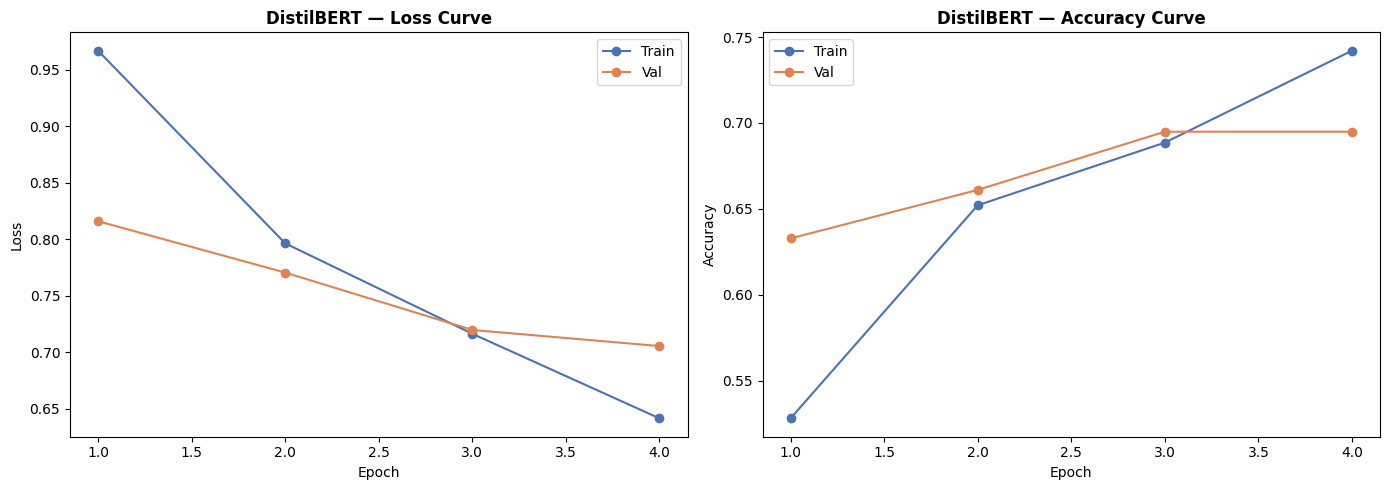

In [16]:
# ── Training Curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_ran = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_ran, history['train_loss'], label='Train', marker='o', color='#4C72B0')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val',   marker='o', color='#DD8452')
axes[0].set_title('DistilBERT — Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(epochs_ran, history['train_acc'], label='Train', marker='o', color='#4C72B0')
axes[1].plot(epochs_ran, history['val_acc'],   label='Val',   marker='o', color='#DD8452')
axes[1].set_title('DistilBERT — Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'bert_training_curves.png', dpi=150)
plt.show()

In [17]:
# ── Test Evaluation ───────────────────────────────────────────────────────
print('Loading best checkpoint...')
model = DistilBertForSequenceClassification.from_pretrained(BERT_DIR).to(DEVICE)

_, _, y_pred, y_true = eval_epoch(model, test_loader)

bert_acc  = accuracy_score(y_true, y_pred)
bert_prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
bert_rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
bert_f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print('=== TEST RESULTS ===')
print(f'Accuracy  : {bert_acc:.4f}')
print(f'Precision : {bert_prec:.4f}')
print(f'Recall    : {bert_rec:.4f}')
print(f'F1-Score  : {bert_f1:.4f}')
print()
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, zero_division=0))

Loading best checkpoint...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

=== TEST RESULTS ===
Accuracy  : 0.7006
Precision : 0.6793
Recall    : 0.7006
F1-Score  : 0.6400

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        11
     neutral       0.80      0.30      0.43        54
    positive       0.69      0.96      0.80       112

    accuracy                           0.70       177
   macro avg       0.50      0.42      0.41       177
weighted avg       0.68      0.70      0.64       177



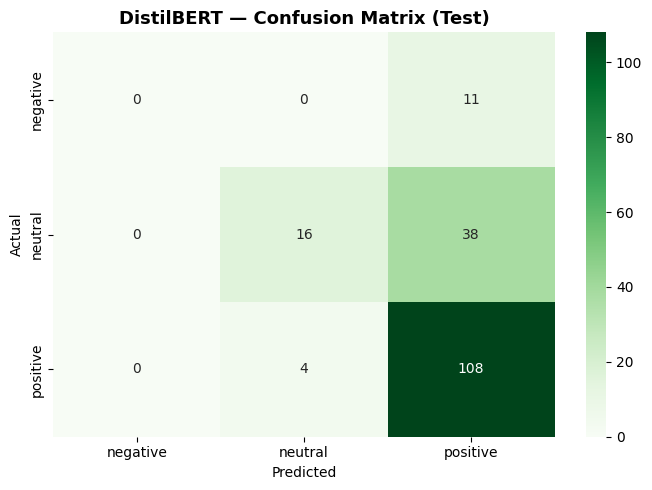

In [18]:
# ── Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title('DistilBERT — Confusion Matrix (Test)', fontsize=13, fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'bert_confusion_test.png', dpi=150)
plt.show()

In [19]:
# ── Save results ──────────────────────────────────────────────────────────
bert_results = {
    'DistilBERT': {
        'accuracy':  round(bert_acc, 4),
        'precision': round(bert_prec, 4),
        'recall':    round(bert_rec, 4),
        'f1':        round(bert_f1, 4),
    }
}
with open(OUTPUT_DIR + 'bert_results.json', 'w') as f:
    json.dump(bert_results, f, indent=2)

print('Saved bert_results.json')
print(f'\nDistilBERT Test Results: {bert_results}')
print('\n⬇ Download from Output tab:')
print('  bert/ folder (entire), bert_confusion_test.png, bert_training_curves.png, bert_results.json')

Saved bert_results.json

DistilBERT Test Results: {'DistilBERT': {'accuracy': 0.7006, 'precision': 0.6793, 'recall': 0.7006, 'f1': 0.64}}

⬇ Download from Output tab:
  bert/ folder (entire), bert_confusion_test.png, bert_training_curves.png, bert_results.json
